In [58]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch

# Set random seed for reproducibility
np.random.seed(23)

In [59]:
# Class 1: Mean [0,0,0], Identity covariance
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.eye(3)
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df_class1 = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df_class1['target'] = 1

# Class 2: Mean [1,1,1], Identity covariance
mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.eye(3)
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df_class2 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df_class2['target'] = 0

# Combine and shuffle
df = pd.concat([df_class1, df_class2], ignore_index=True).sample(frac=1, random_state=23).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (40, 4)


,feature1,feature2,feature3,target
0,-0.331617,-1.632386,0.619114,1
1,1.010229,1.437830,2.327788,0
2,0.241106,-0.952510,-0.136267,1
3,1.676860,4.187503,-0.080565,0
4,2.823378,-0.332863,2.637391,0


In [60]:
fig = px.scatter_3d(
    df, 
    x='feature1', y='feature2', z='feature3',
    color=df['target'].astype(str),
    title='Original 3D Data',
    labels={'color': 'Class'}
)
fig.update_traces(
    marker=dict(size=8, line=dict(width=1.5, color='DarkSlateGray')),
    selector=dict(mode='markers')
)
fig.update_layout(height=600, scene_aspectmode='cube')
fig.show()

In [61]:
# Scale features to mean=0, std=1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df[['feature1', 'feature2', 'feature3']])

# Create new DataFrame with scaled features
df_scaled = df.copy()
df_scaled[['feature1', 'feature2', 'feature3']] = features_scaled

print("Scaled features mean (should be ~0):", df_scaled[['feature1','feature2','feature3']].mean().values)
print("Scaled features std (should be ~1):", df_scaled[['feature1','feature2','feature3']].std().values)

Scaled features mean (should be ~0): [-5.55111512e-17  4.99600361e-17 -2.22044605e-17]
Scaled features std (should be ~1): [1.01273937 1.01273937 1.01273937]


In [62]:
# Compute covariance matrix from scaled features
# FIX: Pass as 2D array and transpose (features as rows for np.cov)
covariance_matrix = np.cov(df_scaled[['feature1', 'feature2', 'feature3']].T)

print("Covariance Matrix:")
print(np.round(covariance_matrix, 4))

Covariance Matrix:
[[1.0256 0.2048 0.0801]
 [0.2048 1.0256 0.1984]
 [0.0801 0.1984 1.0256]]


In [63]:
# Compute eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort by eigenvalues (descending) for PCA convention
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvalues (variance explained):")
for i, val in enumerate(eigenvalues, 1):
    print(f"  PC{i}: {val:.4f} ({val/sum(eigenvalues)*100:.2f}%)")

print("\nEigenvectors (principal components):")
print(np.round(eigenvectors, 4))


Eigenvalues (variance explained):
  PC1: 1.3536 (43.99%)
  PC2: 0.9456 (30.73%)
  PC3: 0.7777 (25.28%)

Eigenvectors (principal components):
[[-0.5388 -0.6936  0.4781]
 [-0.6561 -0.0106 -0.7546]
 [-0.5285  0.7203  0.4494]]


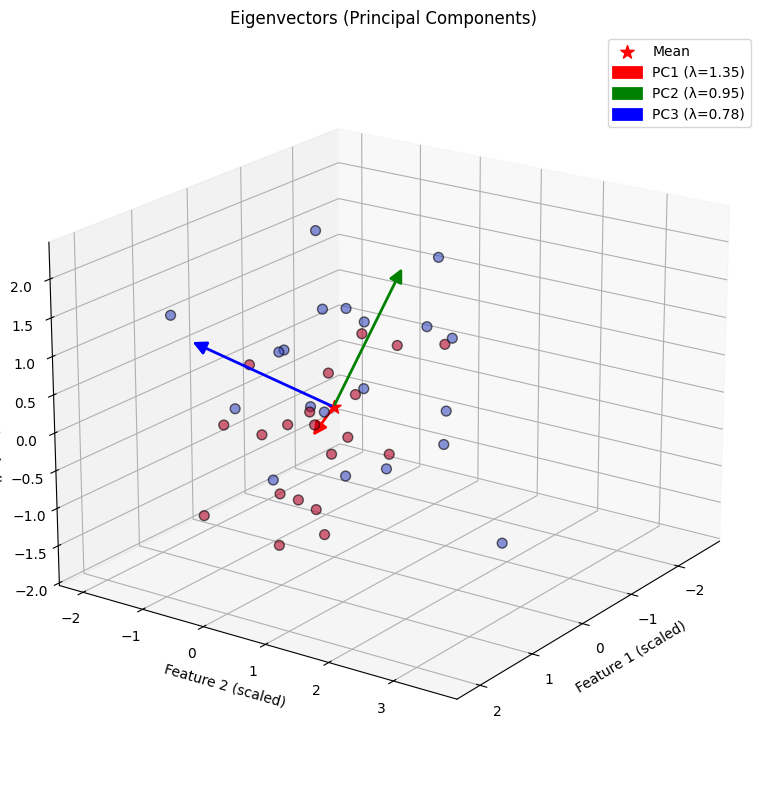

In [64]:
# Custom 3D arrow class for matplotlib 3.4+
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs
    
    def do_3d_projection(self, renderer=None):
        """Required for matplotlib 3.4+ compatibility"""
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)
    
    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        FancyArrowPatch.draw(self, renderer)

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot scaled data points
scatter = ax.scatter(
    df_scaled['feature1'], df_scaled['feature2'], df_scaled['feature3'], 
    c=df_scaled['target'].astype(int), cmap='coolwarm', alpha=0.6, s=50, edgecolors='k'
)

# Plot mean (origin after scaling)
mean_vec = np.zeros(3)
ax.scatter(*mean_vec, color='red', s=100, marker='*', label='Mean')

# Plot eigenvectors as arrows
colors = ['red', 'green', 'blue']
for i, (vec, val) in enumerate(zip(eigenvectors.T, eigenvalues)):
    ax.add_artist(Arrow3D(
        [mean_vec[0], vec[0]*2], 
        [mean_vec[1], vec[1]*2], 
        [mean_vec[2], vec[2]*2],
        mutation_scale=20, lw=2, arrowstyle="-|>", color=colors[i],
        label=f'PC{i+1} (λ={val:.2f})'
    ))

ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
ax.set_zlabel('Feature 3 (scaled)')
ax.set_title('Eigenvectors (Principal Components)')
ax.legend()
ax.view_init(elev=20, azim=35)
plt.tight_layout()
plt.show()

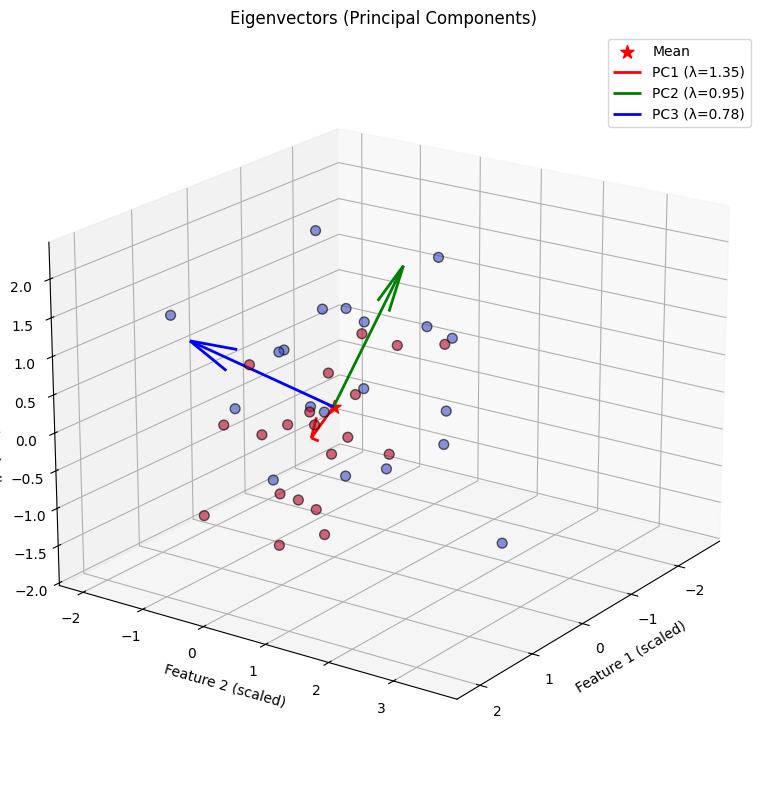

In [65]:

# Simpler 3D plot using quiver (built-in matplotlib function)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot scaled data points
ax.scatter(
    df_scaled['feature1'], df_scaled['feature2'], df_scaled['feature3'], 
    c=df_scaled['target'].astype(int), cmap='coolwarm', alpha=0.6, s=50, edgecolors='k'
)

# Plot mean (origin after scaling)
mean_vec = np.zeros(3)
ax.scatter(*mean_vec, color='red', s=100, marker='*', label='Mean')

# Plot eigenvectors using quiver (much simpler!)
colors = ['red', 'green', 'blue']
for i, (vec, val) in enumerate(zip(eigenvectors.T, eigenvalues)):
    ax.quiver(
        mean_vec[0], mean_vec[1], mean_vec[2],  # Start point
        vec[0]*2, vec[1]*2, vec[2]*2,            # Direction (scaled by 2)
        color=colors[i], linewidth=2, arrow_length_ratio=0.3,
        label=f'PC{i+1} (λ={val:.2f})'
    )

ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
ax.set_zlabel('Feature 3 (scaled)')
ax.set_title('Eigenvectors (Principal Components)')
ax.legend()
ax.view_init(elev=20, azim=35)
plt.tight_layout()
plt.show()

In [66]:
# Select top 2 eigenvectors (principal components)
pc_matrix = eigenvectors[:, :2].T  # Shape: (2, 3)

# Project scaled data: (40,3) × (3,2) → (40,2)
transformed = np.dot(df_scaled[['feature1','feature2','feature3']], pc_matrix.T)

# Create new DataFrame
df_pca = pd.DataFrame(transformed, columns=['PC1', 'PC2'])
df_pca['target'] = df['target'].astype(str)  # Keep original labels

print("Transformed data shape:", df_pca.shape)
df_pca.head()

Transformed data shape: (40, 3)


,PC1,PC2,target
0,1.694055,0.454694,1
1,-1.654764,0.691473,0
2,1.349328,-0.377883,1
3,-2.572050,-1.265530,0
4,-1.544065,-0.194608,0


In [67]:

transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()
     

,PC1,PC2,target
0,-0.929028,-0.104428,1
1,0.704968,2.823547,0
2,-0.886760,-0.265385,1
3,2.030884,1.917130,0
4,-1.763567,3.453593,0


In [68]:
fig = px.scatter(
    df_pca,
    x='PC1', y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.Set1,
    title='PCA: Projection onto First 2 Principal Components',
    labels={'color': 'Class'}
)
fig.update_traces(
    marker=dict(size=10, line=dict(width=1.5, color='DarkSlateGray')),
    selector=dict(mode='markers')
)
fig.update_layout(height=500, width=700)
fig.show()

In [69]:
import plotly.graph_objects as go

variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_var = np.cumsum(variance_ratio)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=['PC1', 'PC2', 'PC3'],
    y=variance_ratio * 100,
    name='Individual Variance',
    marker_color='steelblue'
))
fig.add_trace(go.Scatter(
    x=['PC1', 'PC2', 'PC3'],
    y=cumulative_var * 100,
    name='Cumulative Variance',
    mode='lines+markers',
    marker_color='crimson',
    yaxis='y2'
))
fig.update_layout(
    title='Variance Explained by Each Principal Component',
    xaxis_title='Principal Component',
    yaxis_title='Variance Explained (%)',
    yaxis2=dict(title='Cumulative Variance (%)', overlaying='y', side='right'),
    legend=dict(x=0.02, y=0.98),
    height=400
)
fig.show()

print(f"\nFirst 2 PCs explain {cumulative_var[1]*100:.2f}% of total variance")


First 2 PCs explain 74.72% of total variance


Dataset shape: (40, 4)



Scaled features mean: [-0.  0. -0.]
Scaled features std: [1.012739 1.012739 1.012739]

Covariance Matrix:
[[1.0256 0.2048 0.0801]
 [0.2048 1.0256 0.1984]
 [0.0801 0.1984 1.0256]]

Eigenvalues:
  PC1: 1.3536 (43.99%)
  PC2: 0.9456 (30.73%)
  PC3: 0.7777 (25.28%)

Eigenvectors:
[[-0.5388 -0.6936  0.4781]
 [-0.6561 -0.0106 -0.7546]
 [-0.5285  0.7203  0.4494]]


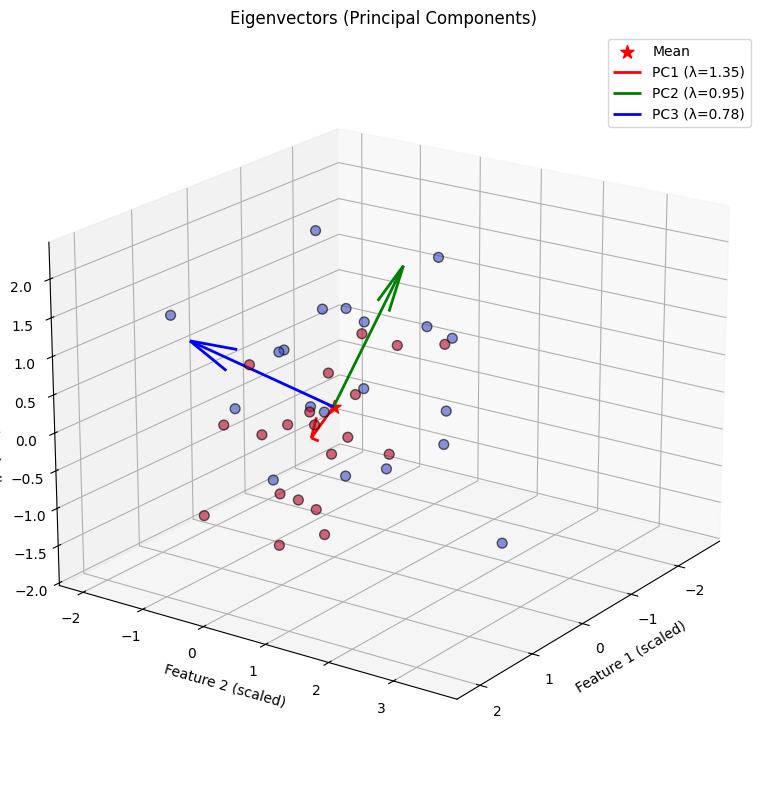


Transformed data shape: (40, 3)
        PC1       PC2 target
0  1.694055  0.454694      1
1 -1.654764  0.691473      0
2  1.349328 -0.377883      1
3 -2.572050 -1.265530      0
4 -1.544065 -0.194608      0



VARIANCE EXPLAINED SUMMARY
PC1: 1.3536 (43.99%) | Cumulative: 43.99%
PC2: 0.9456 (30.73%) | Cumulative: 74.72%
PC3: 0.7777 (25.28%) | Cumulative: 100.00%
First 2 PCs explain 74.72% of total variance


In [70]:
# ============================================================================
# CHUNK 1: Imports (NO %pylab inline!)
# ============================================================================
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(23)

# ============================================================================
# CHUNK 2: Generate Synthetic Data
# ============================================================================
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.eye(3)
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)
df_class1 = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df_class1['target'] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.eye(3)
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)
df_class2 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df_class2['target'] = 0

df = pd.concat([df_class1, df_class2], ignore_index=True).sample(frac=1, random_state=23).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")

# ============================================================================
# CHUNK 3: 3D Visualization (Original Data) - Plotly
# ============================================================================
fig = px.scatter_3d(df, x='feature1', y='feature2', z='feature3',
                    color=df['target'].astype(str),
                    title='Original 3D Data',
                    labels={'color': 'Class'})
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGray')))
fig.update_layout(height=500)
fig.show()

# ============================================================================
# CHUNK 4: Standard Scaling
# ============================================================================
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[['feature1', 'feature2', 'feature3']] = scaler.fit_transform(df[['feature1', 'feature2', 'feature3']])

print("\nScaled features mean:", np.round(df_scaled[['feature1','feature2','feature3']].mean().values, 6))
print("Scaled features std:", np.round(df_scaled[['feature1','feature2','feature3']].std().values, 6))

# ============================================================================
# CHUNK 5: Covariance Matrix (FIXED)
# ============================================================================
covariance_matrix = np.cov(df_scaled[['feature1', 'feature2', 'feature3']].T)
print("\nCovariance Matrix:")
print(np.round(covariance_matrix, 4))

# ============================================================================
# CHUNK 6: Eigenvalues & Eigenvectors
# ============================================================================
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort by eigenvalues descending
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvalues:")
for i, val in enumerate(eigenvalues, 1):
    print(f"  PC{i}: {val:.4f} ({val/sum(eigenvalues)*100:.2f}%)")

print("\nEigenvectors:")
print(np.round(eigenvectors, 4))

# ============================================================================
# CHUNK 7: 3D Visualization with Eigenvectors (USING QUIVER - NO Arrow3D!)
# ============================================================================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot scaled data points
ax.scatter(df_scaled['feature1'], df_scaled['feature2'], df_scaled['feature3'], 
           c=df_scaled['target'].astype(int), cmap='coolwarm', alpha=0.6, s=50, edgecolors='k')

# Plot mean (origin after scaling)
mean_vec = np.zeros(3)
ax.scatter(*mean_vec, color='red', s=100, marker='*', label='Mean')

# Plot eigenvectors using quiver (BUILT-IN, NO CUSTOM CLASS NEEDED!)
colors = ['red', 'green', 'blue']
for i, (vec, val) in enumerate(zip(eigenvectors.T, eigenvalues)):
    ax.quiver(mean_vec[0], mean_vec[1], mean_vec[2],
              vec[0]*2, vec[1]*2, vec[2]*2,
              color=colors[i], linewidth=2, arrow_length_ratio=0.3,
              label=f'PC{i+1} (λ={val:.2f})')

ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
ax.set_zlabel('Feature 3 (scaled)')
ax.set_title('Eigenvectors (Principal Components)')
ax.legend()
ax.view_init(elev=20, azim=35)
plt.tight_layout()
plt.show()

# ============================================================================
# CHUNK 8: Project Data onto First 2 PCs
# ============================================================================
pc_matrix = eigenvectors[:, :2].T
transformed = np.dot(df_scaled[['feature1','feature2','feature3']], pc_matrix.T)

df_pca = pd.DataFrame(transformed, columns=['PC1', 'PC2'])
df_pca['target'] = df['target'].astype(str)

print("\nTransformed data shape:", df_pca.shape)
print(df_pca.head())

# ============================================================================
# CHUNK 9: 2D PCA Visualization - Plotly
# ============================================================================
fig = px.scatter(df_pca, x='PC1', y='PC2', color='target',
                 title='PCA: Projection onto First 2 Principal Components',
                 color_discrete_sequence=px.colors.qualitative.Set1,
                 labels={'color': 'Class'})
fig.update_traces(marker=dict(size=10, line=dict(width=1.5, color='DarkSlateGray')))
fig.update_layout(height=500, width=700)
fig.show()

# ============================================================================
# CHUNK 10: Variance Explained Summary
# ============================================================================
variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_var = np.cumsum(variance_ratio)

print("\n" + "="*60)
print("VARIANCE EXPLAINED SUMMARY")
print("="*60)
for i, (val, ratio, cum) in enumerate(zip(eigenvalues, variance_ratio, cumulative_var), 1):
    print(f"PC{i}: {val:.4f} ({ratio*100:.2f}%) | Cumulative: {cum*100:.2f}%")
print("="*60)
print(f"First 2 PCs explain {cumulative_var[1]*100:.2f}% of total variance")